# Week 6: Understanding the Twin-2K-500 Dataset
### Toubia, Nave, Dreze & Rand (2025) — *Marketing Science*

This notebook is designed to be read **alongside the paper**. Each section begins with a pointer to the relevant paper location so you can read the authors' description, then immediately see it in the data.

**Recommended reading sequence before class:**
- Abstract and Introduction (pp. 1–4): the core question and motivation
- Section 2, Data (pp. 5–12): how participants were recruited and what they were asked
- Section 3, Method (pp. 12–16): how digital twins are constructed from survey data
- Section 4, Results (pp. 16–24): the 71.72% accuracy finding and the normative/nonnormative breakdown

**No API key required. We are only reading and analyzing data.**

---
> **Note on page numbers:** These refer to the working paper version available on SSRN (Toubia et al. 2024/2025). If you are reading the final *Marketing Science* typeset version, section numbers are the same but page numbers may differ by 1–3 pages. Use section headings as your anchor if pages do not match.

## Cell 1 — Loading the Dataset

**Paper anchor: Section 2.1 (Participants), pp. 5–6**

The paper describes recruiting 2,058 US adults through a representative online panel (Prolific). Participants completed surveys across four waves over approximately three months. The authors specifically note that the sample was designed to be representative of the US adult population on age, gender, and ethnicity — this is unusual for behavioral research, which typically relies on convenience samples of students.

The paper also notes (p. 6) that participants answered over 500 questions in total, grouped into six construct domains: demographics, personality and values, cognitive abilities, behavioral economics measures, psychological wellbeing, and product preferences.

**What to look for when this cell runs:** The dataset has 2,058 rows (one per participant) and 4 columns. The `persona_summary` column is what Toubia et al. call the "digital twin prompt" — the text representation of a participant that is fed to GPT-4.

In [ ]:
# CELL 1: Install packages and load the full dataset
# Runtime: ~1-2 minutes. Downloads ~200MB across 7 parquet files.
# Progress bars will appear -- that is normal.

!pip install datasets pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')
from datasets import load_dataset

print("Loading Twin-2K-500 from Hugging Face...")
print()

chunk_files = [
    f"full_persona/chunks/persona_chunk_00{i}.parquet"
    for i in range(1, 8)
]

all_dfs = []
for i, chunk_file in enumerate(chunk_files, 1):
    ds = load_dataset(
        "LLM-Digital-Twin/Twin-2K-500",
        data_files=chunk_file,
        split="train"
    )
    df_chunk = ds.to_pandas()
    all_dfs.append(df_chunk)
    print(f"  Chunk {i}/7: {len(df_chunk)} participants")

df = pd.concat(all_dfs, ignore_index=True)

print()
print(f"Total participants loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()
print("Column descriptions:")
print("  pid             -- participant ID (matches Table 1 in paper)")
print("  persona_text    -- all 500+ raw survey Q&A responses verbatim")
print("  persona_summary -- structured narrative with computed scores")
print("                     THIS is what gets fed to GPT-4 as the twin prompt")
print("  persona_json    -- same data in machine-readable JSON format")
print()
print("Cross-check with paper Section 3.1 (Digital Twin Construction, pp. 12-13):")
print("The persona_summary IS the 'survey-based prompt' the authors describe.")

Loading Twin-2K-500 from Hugging Face...



README.md: 0.00B [00:00, ?B/s]

full_persona/chunks/persona_chunk_001.pa(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  Chunk 1/7: 294 participants


...

Generating train split: 0 examples [00:00, ? examples/s]

  Chunk 6/7: 294 participants


full_persona/chunks/persona_chunk_007.pa(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  Chunk 7/7: 294 participants

Total participants loaded: 2,058
Columns: ['pid', 'persona_text', 'persona_summary', 'persona_json']

Column descriptions:
  pid             -- participant ID (matches Table 1 in paper)
  persona_text    -- all 500+ raw survey Q&A responses verbatim
  persona_summary -- structured narrative with computed scores
                     THIS is what gets fed to GPT-4 as the twin prompt
  persona_json    -- same data in machine-readable JSON format

Cross-check with paper Section 3.1 (Digital Twin Construction, pp. 12-13):
The persona_summary IS the 'survey-based prompt' the authors describe.


---
## Cell 2 — Participant Profile Card

**Paper anchor: Section 2.2 (Survey Instruments), pp. 6–11, and Appendix A**

Table 1 in the paper (p. 7) lists every instrument included in the battery with its source citation, number of items, and the wave in which it was administered. This cell displays the scores for one real participant (PID 574) so you can see what those abstract instrument names look like as actual data.

A few specific instruments to look up in Appendix A while this cell runs:

- **Present bias** is elicited through the convex time budget task (Andreoni & Sprenger 2012). Participants allocate tokens between sooner and later payoffs at varying interest rates. A rational agent's allocation should be consistent across delay lengths; present bias is the degree to which participants treat "now vs. one week" differently from "five weeks vs. six weeks." The rational benchmark is **zero** — any positive value is a departure from consistency.
- **Loss aversion** is elicited through a mixed lottery task in which participants accept or reject gambles that offer equal chances of gaining $X or losing $Y. The coefficient measures how much larger a gain must be to compensate for the possibility of a loss. A value of 1.0 would mean losses and gains are weighted equally; the population average is typically around 2.0.
- **The Big Five** uses the standard 44-item BFI (John & Srivastava 1999), scored on a 1–5 scale.

**What to look for:** Notice how each score comes with a percentile rank. This is how the persona_summary communicates each participant's position in the population distribution — which is exactly what GPT-4 reads when generating a digital twin response.

In [ ]:
# CELL 2: Profile card for participant 574
# This makes concrete what Section 2.2 and Appendix A describe abstractly.

def extract_score(text, score_name):
    pattern = rf"{score_name}\s*=\s*([\-0-9\.]+)"
    match = re.search(pattern, text)
    return float(match.group(1)) if match else None

def extract_percentile(text, score_name):
    pattern = rf"{score_name}\s*=\s*[\-0-9\.]+\s*\((\d+)(?:st|nd|rd|th) percentile\)"
    match = re.search(pattern, text)
    return int(match.group(1)) if match else None

def extract_demo(text, field):
    pattern = rf"{field}:\s*(.+)"
    match = re.search(pattern, text)
    return match.group(1).strip() if match else "--"

def score_bar(percentile, width=20):
    """ASCII bar showing where a score sits in the population distribution."""
    if percentile is None:
        return "[" + "?" * width + "]"
    filled = int(round(percentile / 100 * width))
    bar = "#" * filled + "-" * (width - filled)
    return f"[{bar}] {percentile}th pct"

row = df[df["pid"] == "574"].iloc[0]
s = row["persona_summary"]

print("=" * 65)
print("  PARTICIPANT PROFILE CARD -- PID 574")
print("  Cross-reference: Paper Section 2.2, pp. 6-11 and Appendix A")
print("=" * 65)
print()

print("DEMOGRAPHICS  (paper: Section 2.1, Table 1, p. 7)")
print("-" * 55)
for field in [
    "Geographic region", "Gender", "Age", "Education level",
    "Income", "Political affiliation", "Political views",
    "Employment status", "Marital status"
]:
    print(f"  {field:<26} {extract_demo(s, field)}")

print()
print("PERSONALITY -- Big Five  (paper: Appendix A, BFI, John & Srivastava 1999)")
print("Scale 1-5. Bar shows percentile rank within the 2,058-participant sample.")
print("-" * 55)
for label, key in [
    ("Openness",          "score_openness"),
    ("Conscientiousness", "wave1_score_conscientiousness"),
    ("Extraversion",      "score_extraversion"),
    ("Agreeableness",     "score_agreeableness"),
    ("Neuroticism",       "score_neuroticism"),
]:
    score = extract_score(s, key)
    pct   = extract_percentile(s, key)
    val   = f"{score:.2f}" if score else "--"
    print(f"  {label:<22} {val}   {score_bar(pct)}")

print()
print("BEHAVIORAL ECONOMICS  (paper: Appendix A, incentivized choice tasks)")
print("These are REVEALED preferences from incentive-compatible tasks,")
print("not self-reported attitudes. See paper pp. 8-10 for task descriptions.")
print("-" * 55)
for label, key, description in [
    ("Present Bias",  "score_presentbias",
     "Rational benchmark = 0. Source: Convex Time Budget (Andreoni & Sprenger 2012)"),
    ("Loss Aversion", "score_lossaversion",
     "1.0 = symmetric. ~2.0 typical. Source: Mixed lottery task"),
    ("Risk Aversion", "score_riskaversion",
     "Higher = more risk averse. Source: Lottery choice task"),
    ("Discount Rate", "score_discount",
     "Annual discount rate implied by intertemporal choices"),
]:
    score = extract_score(s, key)
    pct   = extract_percentile(s, key)
    val   = f"{score:.3f}" if score is not None else "--"
    print(f"  {label:<20} {val}   {score_bar(pct)}")
    print(f"  {'':20} -> {description}")
    print()

print("COGNITIVE ABILITIES  (paper: Appendix A, pp. various)")
print("-" * 55)
for label, key, source in [
    ("Financial Literacy", "score_finliteracy",
     "Lusardi & Mitchell (2011), 8 items"),
    ("Numeracy",           "score_numeracy",
     "Schwartz et al. (1997), 7 items"),
    ("Fluid Intelligence", "score_fluid",
     "Spatial reasoning matrix puzzles"),
    ("Need for Cognition", "score_needforcognition",
     "Cacioppo & Petty (1982), 18 items"),
]:
    score = extract_score(s, key)
    pct   = extract_percentile(s, key)
    val   = f"{score:.2f}" if score is not None else "--"
    print(f"  {label:<22} {val}   {score_bar(pct)}")
    print(f"  {'':22}    Source: {source}")

print()
print("SELF-CONCEPT RESPONSES  (paper: Appendix A, Higgins 1987 self-discrepancy)")
print("These open-ended responses are included verbatim in the persona_summary")
print("and give GPT-4 the participant's own voice, not just scores.")
print("-" * 55)
self_answers = re.findall(r'They answered: "([^"]+)"', s)
for label, answer in zip(
    ["Aspires to be:", "Ought to be:", "Actually is:"],
    self_answers[:3]
):
    print(f"  {label}")
    print(f"    {answer.strip()}")
    print()

print("=" * 65)
print("KEY INSIGHT FOR BNPL RESEARCH:")
print("PID 574 has HIGH present bias (87th pct) AND high loss aversion (88th pct).")
print("These two traits pull in opposite directions on BNPL adoption:")
print("  Present bias  -> attracted to 'buy now, pay later'")
print("  Loss aversion -> worried about the pain of future payments")
print("This tension is theoretically interesting and is the real-person")
print("equivalent of Carmen from our Phase 1 synthetic personas.")
print("=" * 65)

  PARTICIPANT PROFILE CARD -- PID 574
  Cross-reference: Paper Section 2.2, pp. 6-11 and Appendix A

DEMOGRAPHICS  (paper: Section 2.1, Table 1, p. 7)
-------------------------------------------------------
  Geographic region          South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL)
  Gender                     Male
  Age                        18-29
  Education level            Some college, no degree
  Income                     $100,000 or more
  Political affiliation      Republican
  Political views            Conservative
  Employment status          Student
  Marital status             Never been married

PERSONALITY -- Big Five  (paper: Appendix A, BFI, John & Srivastava 1999)
Scale 1-5. Bar shows percentile rank within the 2,058-participant sample.
-------------------------------------------------------
  Openness               3.60   [########------------] 41th pct
  Conscientiousness      4.00   [###########---------] 53th pct
  Extraversion       

---
## Cell 3 — Score Distributions Across All 2,058 Participants

**Paper anchor: Section 2.3 (Descriptive Statistics) and Table 2, pp. 11–12**

Table 2 in the paper reports means and standard deviations for the key measures. This cell produces histograms so you can see the full shape of those distributions — not just means, but skewness, bimodality, and outliers.

Two things to pay attention to as the plots appear:

1. **Compare your distributions to Table 2.** Do the means you see in the histograms match the paper's reported means? If they don't match exactly, it may be because the paper reports a different wave or uses a slightly different scoring method. Small discrepancies are normal and worth discussing.

2. **Notice the range.** The paper emphasizes (Section 1, p. 3) that the motivation for using a representative panel rather than a convenience sample is to capture genuine population heterogeneity. The width of these distributions is the evidence for that claim — you are seeing the actual variation, not just being told it exists.

PID 574 is marked with a red dashed line on each plot. The dotted black line is the sample mean.

Extracting scores for all participants...
Participants with complete scores: 664 of 2,058



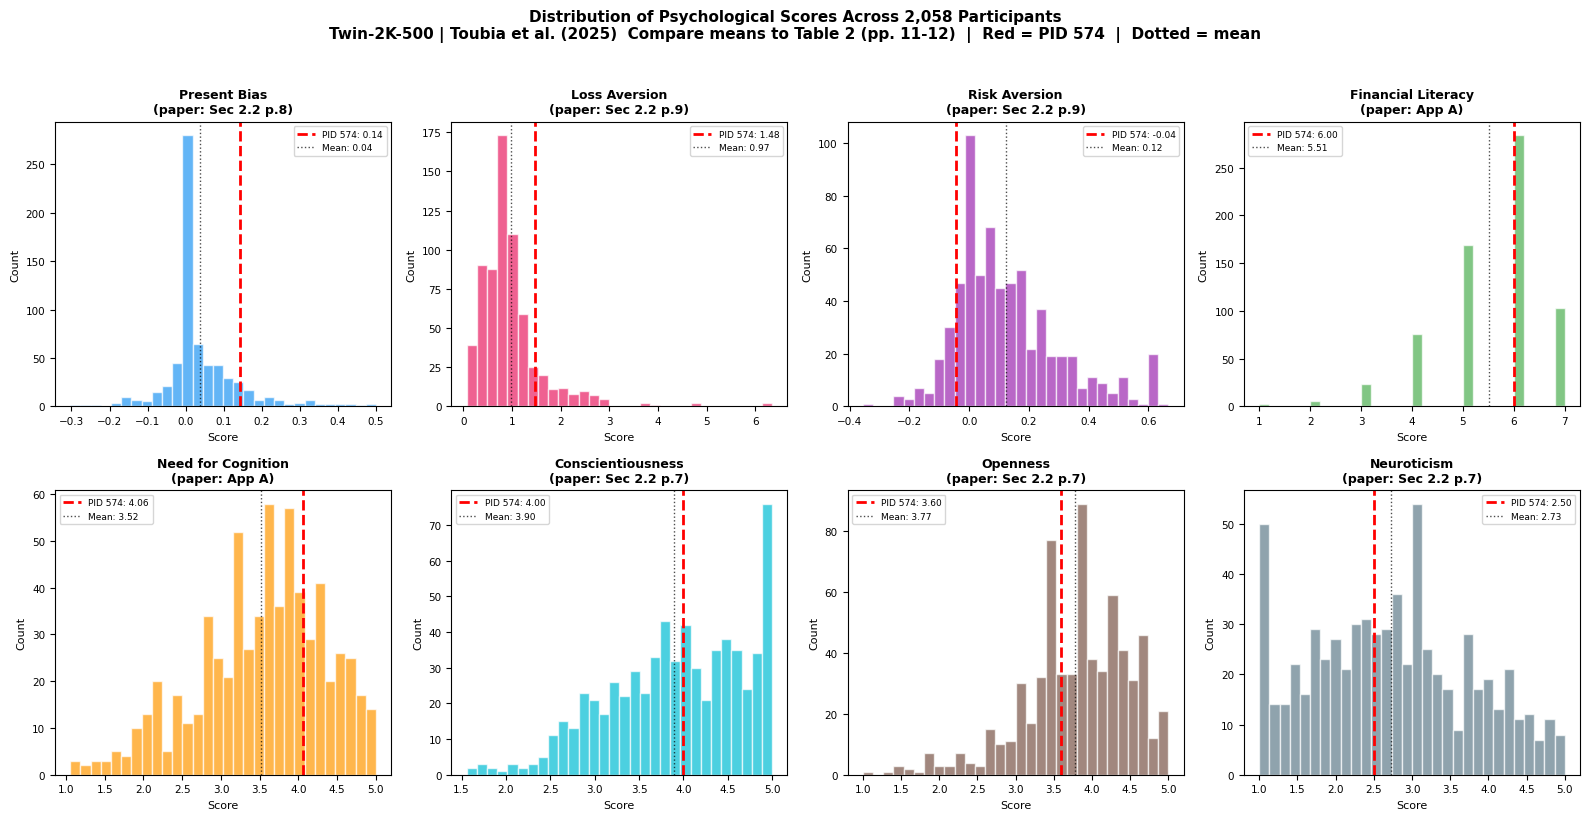


COMPARE TO TABLE 2 IN PAPER (pp. 11-12):
-------------------------------------------------------
Score                    Our Mean     Our SD
-------------------------------------------------------
Present Bias                0.039      0.100
Loss Aversion               0.968      0.663
Risk Aversion               0.125      0.175
Financial Literacy          5.509      1.094
Need for Cognition          3.522      0.813
Conscientiousness           3.899      0.748
Openness                    3.775      0.691
Neuroticism                 2.730      1.029

If these differ from Table 2, note the discrepancy and discuss:
Could be wave differences, scoring method, or version of dataset.


In [ ]:
# CELL 3: Distributions of key psychological scores
# Cross-reference: Table 2 (Descriptive Statistics), paper pp. 11-12
# Runtime: ~30 seconds for score extraction.

print("Extracting scores for all participants...")

score_definitions = {
    "present_bias":       "score_presentbias",
    "loss_aversion":      "score_lossaversion",
    "risk_aversion":      "score_riskaversion",
    "financial_literacy": "score_finliteracy",
    "need_for_cognition": "score_needforcognition",
    "conscientiousness":  "wave1_score_conscientiousness",
    "openness":           "score_openness",
    "neuroticism":        "score_neuroticism",
}

for col, key in score_definitions.items():
    df[col] = df["persona_summary"].apply(lambda x: extract_score(x, key))

df_scores = df.dropna(subset=list(score_definitions.keys())).copy()
print(f"Participants with complete scores: {len(df_scores):,} of {len(df):,}")
print()

p574 = df_scores[df_scores["pid"] == "574"].iloc[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    "Distribution of Psychological Scores Across 2,058 Participants\n"
    "Twin-2K-500 | Toubia et al. (2025)  "
    "Compare means to Table 2 (pp. 11-12)  |  Red = PID 574  |  Dotted = mean",
    fontsize=11, fontweight="bold", y=1.02
)

plot_configs = [
    ("present_bias",       "Present Bias",        "#2196F3", "Sec 2.2 p.8"),
    ("loss_aversion",      "Loss Aversion",       "#E91E63", "Sec 2.2 p.9"),
    ("risk_aversion",      "Risk Aversion",       "#9C27B0", "Sec 2.2 p.9"),
    ("financial_literacy", "Financial Literacy",  "#4CAF50", "App A"),
    ("need_for_cognition", "Need for Cognition",  "#FF9800", "App A"),
    ("conscientiousness",  "Conscientiousness",   "#00BCD4", "Sec 2.2 p.7"),
    ("openness",           "Openness",            "#795548", "Sec 2.2 p.7"),
    ("neuroticism",        "Neuroticism",         "#607D8B", "Sec 2.2 p.7"),
]

for ax, (col, label, color, ref) in zip(axes.flat, plot_configs):
    data = df_scores[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(p574[col], color="red", linewidth=2,
               linestyle="--", label=f"PID 574: {p574[col]:.2f}")
    ax.axvline(data.mean(), color="black", linewidth=1,
               linestyle=":", alpha=0.7, label=f"Mean: {data.mean():.2f}")
    ax.set_title(f"{label}\n(paper: {ref})", fontweight="bold", fontsize=9)
    ax.set_xlabel("Score", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.legend(fontsize=6.5)
    ax.tick_params(labelsize=7.5)

plt.tight_layout()
plt.show()

print()
print("COMPARE TO TABLE 2 IN PAPER (pp. 11-12):")
print("-" * 55)
print(f"{'Score':<22} {'Our Mean':>10} {'Our SD':>10}")
print("-" * 55)
for col, label, _, _ in plot_configs:
    d = df_scores[col].dropna()
    print(f"{label:<22} {d.mean():>10.3f} {d.std():>10.3f}")
print()
print("If these differ from Table 2, note the discrepancy and discuss:")
print("Could be wave differences, scoring method, or version of dataset.")

---
## Cell 4 — Normative vs. Nonnormative Accuracy

**Paper anchor: Section 4.2 (Accuracy by Question Type), pp. 18–22, and Table 3**

This is the most important empirical finding in the paper for our purposes. Table 3 (p. 19) shows twin accuracy broken down by question category. The headline numbers are:

- Overall twin accuracy: **71.72%**
- Human retest baseline: **81.72%**
- Gap attributable to nonnormative questions: the paper estimates this accounts for most of the ~10 point difference

Section 4.2 then examines five specific behavioral biases (pp. 19–22):
1. **Sunk cost fallacy** — twins do not show it; they correctly ignore past costs
2. **Allais paradox** — twins prefer the higher expected-value lottery; humans prefer the certain option
3. **Omission bias** — twins judge harms by outcome not by act; humans judge actions as worse than inactions
4. **Probability matching** — twins always bet on the most likely outcome; many humans match their bets to the probabilities
5. **Anchoring** — twins show less anchoring than humans on numeric estimation tasks

**What to look for in this cell:** The financial literacy distribution is tight and right-skewed — most people score high on an objective knowledge test. A twin reading "91st percentile financial literacy" in the persona_summary can answer these questions reliably. Present bias is wide and mostly above zero — this is a nonnormative departure from rational behavior that GPT-4 tends not to spontaneously replicate.

**Discussion question for class:** If twins underperform on nonnormative questions, what does this mean for using digital twins to study BNPL? (Hint: present bias is itself a nonnormative construct.)

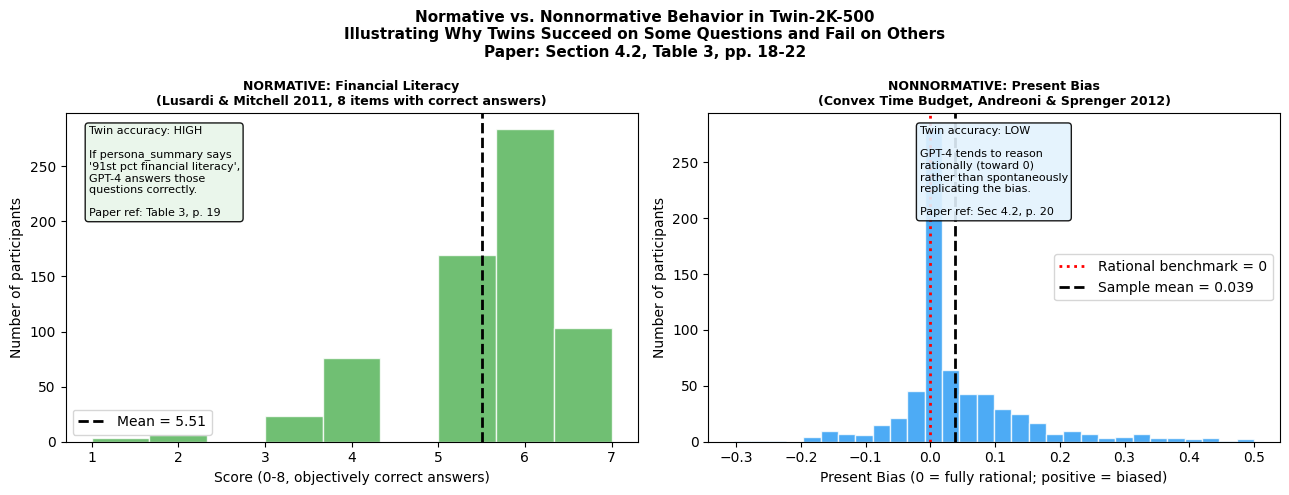


KEY NUMBERS FROM TOUBIA ET AL. (Table 3, p. 19):

  Overall twin accuracy:       71.72%
  Human retest baseline:       81.72%
  Gap:                         ~10 percentage points

  The gap is NOT uniform -- it is concentrated in nonnormative questions.
  On normative questions (financial literacy, numeracy, Big Five):
    twins perform close to the human baseline.
  On nonnormative questions (anchoring, Allais, sunk cost, etc.):
    twin accuracy drops significantly below baseline.

IMPLICATION FOR OUR BNPL RESEARCH:
  Present bias IS a nonnormative construct -- it is literally
  a departure from rational intertemporal choice.
  Our twins will reflect the profile of a present-biased person
  (attitudes, stated preferences) but may not exhibit the bias
  as spontaneously as the real person would in an actual purchase.
  This is a limitation we must acknowledge in the paper.


In [ ]:
# CELL 4: Normative vs. Nonnormative behavior
# Cross-reference: Section 4.2 and Table 3, paper pp. 18-22

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Normative vs. Nonnormative Behavior in Twin-2K-500\n"
    "Illustrating Why Twins Succeed on Some Questions and Fail on Others\n"
    "Paper: Section 4.2, Table 3, pp. 18-22",
    fontsize=11, fontweight="bold"
)

# Left: Financial literacy (normative -- objective correct answers exist)
ax1 = axes[0]
fl = df_scores["financial_literacy"].dropna()
ax1.hist(fl, bins=9, color="#4CAF50", alpha=0.8, edgecolor="white")
ax1.axvline(fl.mean(), color="black", linewidth=2,
            linestyle="--", label=f"Mean = {fl.mean():.2f}")
ax1.set_title(
    "NORMATIVE: Financial Literacy\n"
    "(Lusardi & Mitchell 2011, 8 items with correct answers)",
    fontweight="bold", fontsize=9
)
ax1.set_xlabel("Score (0-8, objectively correct answers)")
ax1.set_ylabel("Number of participants")
ax1.legend()
ax1.text(0.04, 0.96,
    "Twin accuracy: HIGH\n"
    "\n"
    "If persona_summary says\n"
    "'91st pct financial literacy',\n"
    "GPT-4 answers those\n"
    "questions correctly.\n"
    "\n"
    "Paper ref: Table 3, p. 19",
    transform=ax1.transAxes, fontsize=8,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="#E8F5E9", alpha=0.9)
)

# Right: Present bias (nonnormative -- rational benchmark is 0)
ax2 = axes[1]
pb = df_scores["present_bias"].dropna()
ax2.hist(pb, bins=30, color="#2196F3", alpha=0.8, edgecolor="white")
ax2.axvline(0, color="red", linewidth=2,
            linestyle=":", label="Rational benchmark = 0")
ax2.axvline(pb.mean(), color="black", linewidth=2,
            linestyle="--", label=f"Sample mean = {pb.mean():.3f}")
ax2.set_title(
    "NONNORMATIVE: Present Bias\n"
    "(Convex Time Budget, Andreoni & Sprenger 2012)",
    fontweight="bold", fontsize=9
)
ax2.set_xlabel("Present Bias (0 = fully rational; positive = biased)")
ax2.set_ylabel("Number of participants")
ax2.legend()
ax2.text(0.37, 0.96,
    "Twin accuracy: LOW\n"
    "\n"
    "GPT-4 tends to reason\n"
    "rationally (toward 0)\n"
    "rather than spontaneously\n"
    "replicating the bias.\n"
    "\n"
    "Paper ref: Sec 4.2, p. 20",
    transform=ax2.transAxes, fontsize=8,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="#E3F2FD", alpha=0.9)
)

plt.tight_layout()
plt.show()

print()
print("KEY NUMBERS FROM TOUBIA ET AL. (Table 3, p. 19):")
print()
print("  Overall twin accuracy:       71.72%")
print("  Human retest baseline:       81.72%")
print("  Gap:                         ~10 percentage points")
print()
print("  The gap is NOT uniform -- it is concentrated in nonnormative questions.")
print("  On normative questions (financial literacy, numeracy, Big Five):")
print("    twins perform close to the human baseline.")
print("  On nonnormative questions (anchoring, Allais, sunk cost, etc.):")
print("    twin accuracy drops significantly below baseline.")
print()
print("IMPLICATION FOR OUR BNPL RESEARCH:")
print("  Present bias IS a nonnormative construct -- it is literally")
print("  a departure from rational intertemporal choice.")
print("  Our twins will reflect the profile of a present-biased person")
print("  (attitudes, stated preferences) but may not exhibit the bias")
print("  as spontaneously as the real person would in an actual purchase.")
print("  This is a limitation we must acknowledge in the paper.")

---
## Cell 5 — Consumer Heterogeneity Map

**Paper anchor: Section 1 (Introduction), pp. 1–4, and Section 5 (Discussion), pp. 22–26**

The paper's motivating argument (pp. 2–3) is that consumer heterogeneity is large enough that aggregate models miss important variation — and that interviewing real consumers at scale is impractical. Digital twins are proposed as a solution: simulate the responses of many heterogeneous consumers at low cost.

This scatter plot makes that heterogeneity visible. We plot every participant's present bias score against their loss aversion score. If these two traits were highly correlated, you would see a diagonal line — knowing one would tell you the other. If they are independent, you would see a scattered cloud.

**What to look for:** The shape of the cloud and the correlation reported at the bottom of the cell. A near-zero correlation is the key finding here — it means present bias and loss aversion are largely independent dimensions of variation. This directly motivates the Phase 2 notebook: if the traits were correlated, we could describe consumers with one number. Because they are not, we need both, and the four quadrants of the plot represent genuinely different consumer types.

**Discussion question for class:** The paper discusses (Section 5, p. 24) how digital twins could be used to run large-scale heterogeneity analyses. How does this scatter plot illustrate both the opportunity and the challenge of doing that?

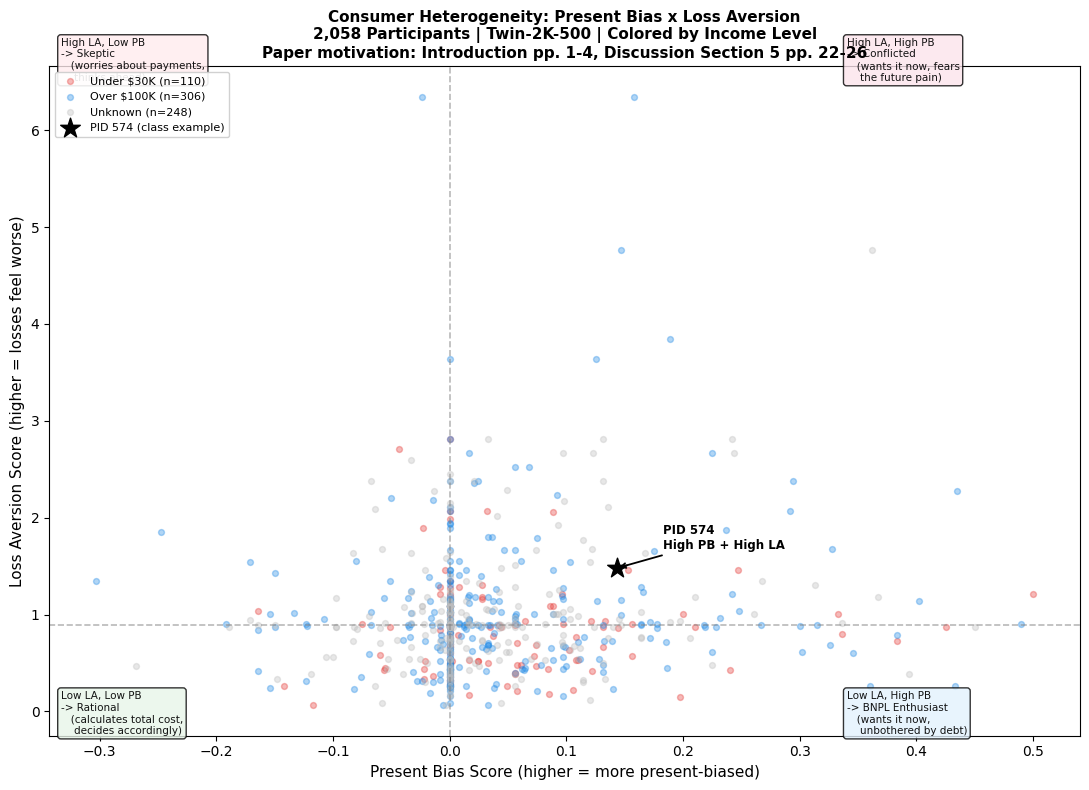


SUMMARY STATISTICS (compare to Table 2, paper pp. 11-12)
-------------------------------------------------------
Trait                      Mean       SD      Min      Max
-------------------------------------------------------
Present Bias              0.039    0.100   -0.303    0.500
Loss Aversion             0.968    0.663    0.064    6.347
Risk Aversion             0.125    0.175   -0.356    0.667

Correlation: Present Bias x Loss Aversion  r = 0.124

Near-zero correlation: the two traits are largely INDEPENDENT.
Knowing someone's present bias score tells you almost nothing
about their loss aversion -- and vice versa.

This is why all four quadrants of the scatter plot are populated.
A researcher who measured only present bias would miss the
Skeptic and Conflicted quadrants entirely.

BRIDGE TO PHASE 2:
In the next notebook, we select one real participant from each quadrant
and use their full persona_summary as the GPT-4 system prompt.
The four quadrants define our sampling strate

In [ ]:
# CELL 5: Consumer heterogeneity map
# Cross-reference: Introduction pp. 1-4, Discussion Section 5 pp. 22-26
# The quadrant structure is our own addition for BNPL research --
# it is not in the paper, but follows directly from the paper's framework.

def extract_income(text):
    match = re.search(r"Income:\s*(.+)", text)
    if not match:
        return "Unknown"
    val = match.group(1).strip()
    if "Less than" in val:
        return "Under $30K"
    elif "30,000-50" in val:
        return "$30K-$50K"
    elif "50,000-75" in val:
        return "$50K-$75K"
    elif "75,000-100" in val:
        return "$75K-$100K"
    elif "100,000" in val:
        return "Over $100K"
    return "Unknown"

df_scores["income"] = df_scores["persona_summary"].apply(extract_income)

fig, ax = plt.subplots(figsize=(11, 8))

income_colors = {
    "Under $30K":  "#E53935",
    "$30K-$50K":   "#FB8C00",
    "$50K-$75K":   "#FDD835",
    "$75K-$100K":  "#43A047",
    "Over $100K":  "#1E88E5",
    "Unknown":     "#BDBDBD",
}

for income_level, color in income_colors.items():
    subset = df_scores[df_scores["income"] == income_level]
    if len(subset) > 0:
        ax.scatter(
            subset["present_bias"], subset["loss_aversion"],
            c=color, alpha=0.35, s=18,
            label=f"{income_level} (n={len(subset)})"
        )

# Highlight PID 574
ax.scatter(
    p574["present_bias"], p574["loss_aversion"],
    c="black", s=220, zorder=5, marker="*",
    label="PID 574 (class example)"
)
ax.annotate(
    "PID 574\nHigh PB + High LA",
    xy=(p574["present_bias"], p574["loss_aversion"]),
    xytext=(p574["present_bias"] + 0.04, p574["loss_aversion"] + 0.2),
    fontsize=8.5, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.3)
)

# Quadrant dividers at sample median
xmed = df_scores["present_bias"].median()
ymed = df_scores["loss_aversion"].median()
ax.axvline(xmed, color="gray", linewidth=1.2, linestyle="--", alpha=0.55)
ax.axhline(ymed, color="gray", linewidth=1.2, linestyle="--", alpha=0.55)

xlim = ax.get_xlim()
ylim = ax.get_ylim()
for x, y, txt, fc in [
    (xlim[0]+0.01, ylim[1]-0.15,
     "High LA, Low PB\n-> Skeptic\n   (worries about payments,\n    thinks ahead)",
     "#FFEBEE"),
    (xlim[1]-0.20, ylim[1]-0.15,
     "High LA, High PB\n-> Conflicted\n   (wants it now, fears\n    the future pain)",
     "#FCE4EC"),
    (xlim[0]+0.01, ylim[0]+0.02,
     "Low LA, Low PB\n-> Rational\n   (calculates total cost,\n    decides accordingly)",
     "#E8F5E9"),
    (xlim[1]-0.20, ylim[0]+0.02,
     "Low LA, High PB\n-> BNPL Enthusiast\n   (wants it now,\n    unbothered by debt)",
     "#E3F2FD"),
]:
    ax.text(x, y, txt, fontsize=7.5, alpha=0.92,
            bbox=dict(boxstyle="round", facecolor=fc, alpha=0.8))

ax.set_xlabel("Present Bias Score (higher = more present-biased)", fontsize=11)
ax.set_ylabel("Loss Aversion Score (higher = losses feel worse)", fontsize=11)
ax.set_title(
    "Consumer Heterogeneity: Present Bias x Loss Aversion\n"
    "2,058 Participants | Twin-2K-500 | Colored by Income Level\n"
    "Paper motivation: Introduction pp. 1-4, Discussion Section 5 pp. 22-26",
    fontsize=11, fontweight="bold"
)
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

# Summary statistics
print()
print("SUMMARY STATISTICS (compare to Table 2, paper pp. 11-12)")
print("-" * 55)
print(f"{'Trait':<22} {'Mean':>8} {'SD':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)
for col, label in [
    ("present_bias",  "Present Bias"),
    ("loss_aversion", "Loss Aversion"),
    ("risk_aversion", "Risk Aversion"),
]:
    d = df_scores[col].dropna()
    print(f"{label:<22} {d.mean():>8.3f} {d.std():>8.3f} "
          f"{d.min():>8.3f} {d.max():>8.3f}")

corr = df_scores[["present_bias", "loss_aversion"]].corr().iloc[0, 1]
print()
print(f"Correlation: Present Bias x Loss Aversion  r = {corr:.3f}")
print()
if abs(corr) < 0.15:
    print("Near-zero correlation: the two traits are largely INDEPENDENT.")
    print("Knowing someone's present bias score tells you almost nothing")
    print("about their loss aversion -- and vice versa.")
    print()
    print("This is why all four quadrants of the scatter plot are populated.")
    print("A researcher who measured only present bias would miss the")
    print("Skeptic and Conflicted quadrants entirely.")
else:
    print(f"Non-trivial correlation (r = {corr:.3f}) -- worth investigating.")
print()
print("BRIDGE TO PHASE 2:")
print("In the next notebook, we select one real participant from each quadrant")
print("and use their full persona_summary as the GPT-4 system prompt.")
print("The four quadrants define our sampling strategy -- grounded in this data.")